# Labwork 3: Hello, CUDA!

In [1]:
import math
import time

import numpy as np
import matplotlib.pyplot as plt
from numba import cuda

In [4]:
img = plt.imread("/content/images.jpeg")

imageHeight, imageWidth = img.shape[:2]
pixelCount = imageHeight * imageWidth
flatSrc = img.reshape(pixelCount, 3)

print("Image shape:", img.shape)

Image shape: (364, 549, 3)


CPU time: 0.25618839263916016


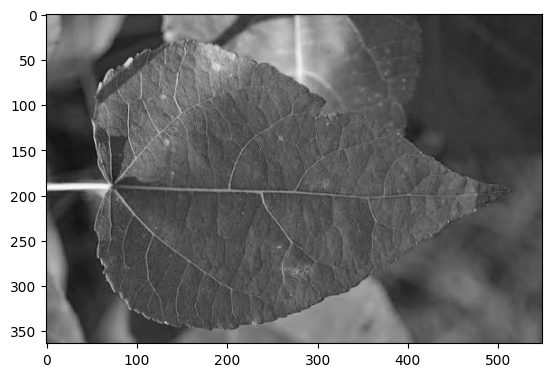

In [5]:
def grayscale_cpu(src):
    dst = np.empty_like(src)
    for i in range(pixelCount):
        g = (int(src[i, 0]) + int(src[i, 1]) + int(src[i, 2])) // 3
        dst[i, 0] = dst[i, 1] = dst[i, 2] = g
    return dst


start = time.time()
cpuDst = grayscale_cpu(flatSrc)
cpuTime = time.time() - start
print("CPU time:", cpuTime)

plt.imsave("gray_cpu.png", cpuDst.reshape(imageHeight, imageWidth, 3))
plt.imshow(cpuDst.reshape(imageHeight, imageWidth, 3))
plt.show()

GPU time: 0.0018544197082519531
Speedup: 138.15016713808177
Same result as CPU: True


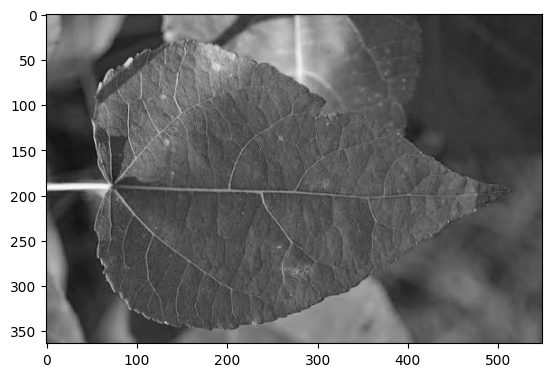

In [7]:
@cuda.jit
def grayscale_gpu(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if tidx < src.shape[0]:
        g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
        dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g


blockSize = 64
gridSize = math.ceil(pixelCount / blockSize)

devSrc = cuda.to_device(flatSrc)
devDst = cuda.device_array((pixelCount, 3), np.uint8)
grayscale_gpu[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()

start = time.time()
devSrc = cuda.to_device(flatSrc)
devDst = cuda.device_array((pixelCount, 3), np.uint8)
grayscale_gpu[gridSize, blockSize](devSrc, devDst)
gpuDst = devDst.copy_to_host()
gpuTime = time.time() - start
print("GPU time:", gpuTime)
print("Speedup:", cpuTime / gpuTime)
print("Same result as CPU:", np.array_equal(cpuDst, gpuDst))

plt.imsave("gray_gpu.png", gpuDst.reshape(imageHeight, imageWidth, 3))
plt.imshow(gpuDst.reshape(imageHeight, imageWidth, 3))
plt.show()

8 24980 0.21663665771484375
16 12490 0.10983943939208984
32 6245 0.05568504333496094
64 3123 0.053315162658691406
128 1562 0.053076744079589844
256 781 0.05393028259277344
512 391 0.05421161651611328
1024 196 0.05668163299560547


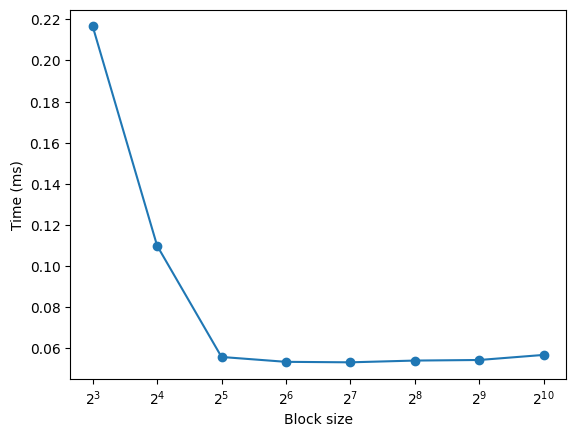

In [9]:
blockSizes = [8, 16, 32, 64, 128, 256, 512, 1024]
times = []

for blockSize in blockSizes:
    gridSize = math.ceil(pixelCount / blockSize)
    start = time.time()
    for _ in range(50):
        grayscale_gpu[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()
    times.append((time.time() - start) / 50 * 1000)
    print(blockSize, gridSize, times[-1])

plt.plot(blockSizes, times, marker="o")
plt.xscale("log", base=2)
plt.xlabel("Block size")
plt.ylabel("Time (ms)")
plt.savefig("blocksize_vs_time.png")
plt.show()